In [166]:
%reset -f

# Distribution of the suggested deals for case studies

## Plots for the suggested deals
The Script creates bar charts for the preferred deals (e.g. A1,B2,C1 etc.).

Each stakeholder was given a moderator role, resulting in 3 classes of the simulations. The moderator launches the conversation by proposing the deal that best aligns with its preferences, as well as making a final proposal.


*   **Input:** Path (*string*) to an Excel file with the stored deals and the decision on whether the generated plots should be saved as *PNG*s
*   **Output:** 3 bar charts representing the preferred deals in each class of the simulations as well as a bar chart combining all deal preferences








Please enter the path to the Excel file: /content/Results_overview_Bt_plots.xlsx
Do you want to save the plots as PNGs? (yes/no): yes


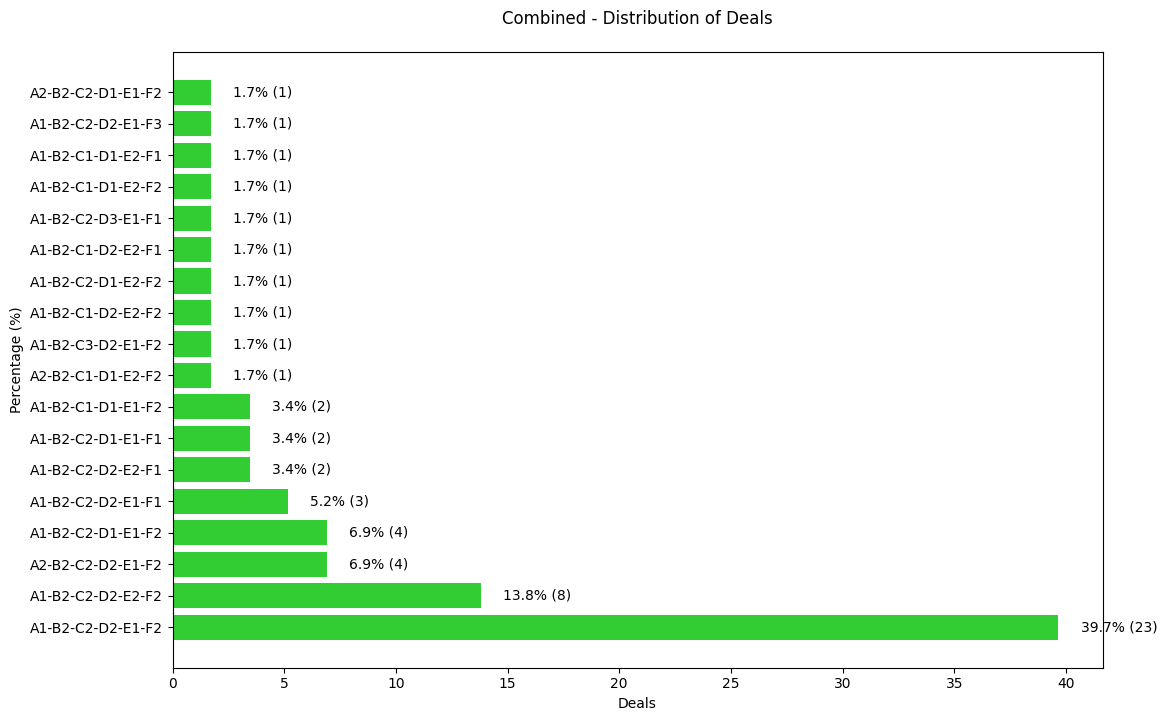

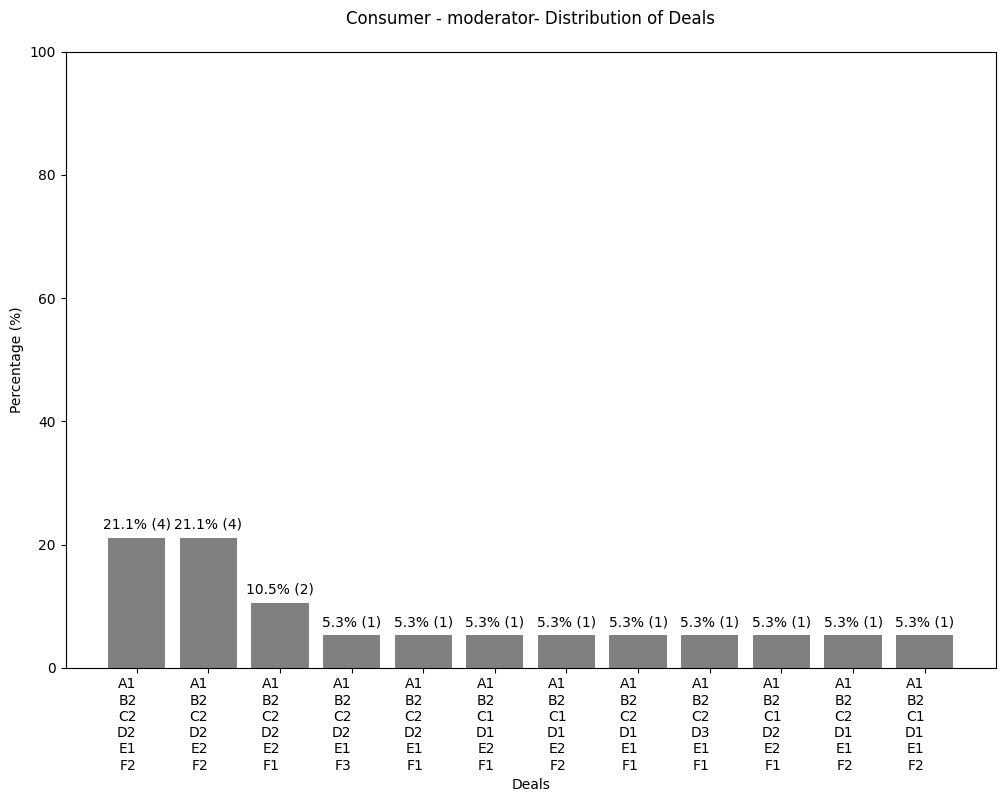

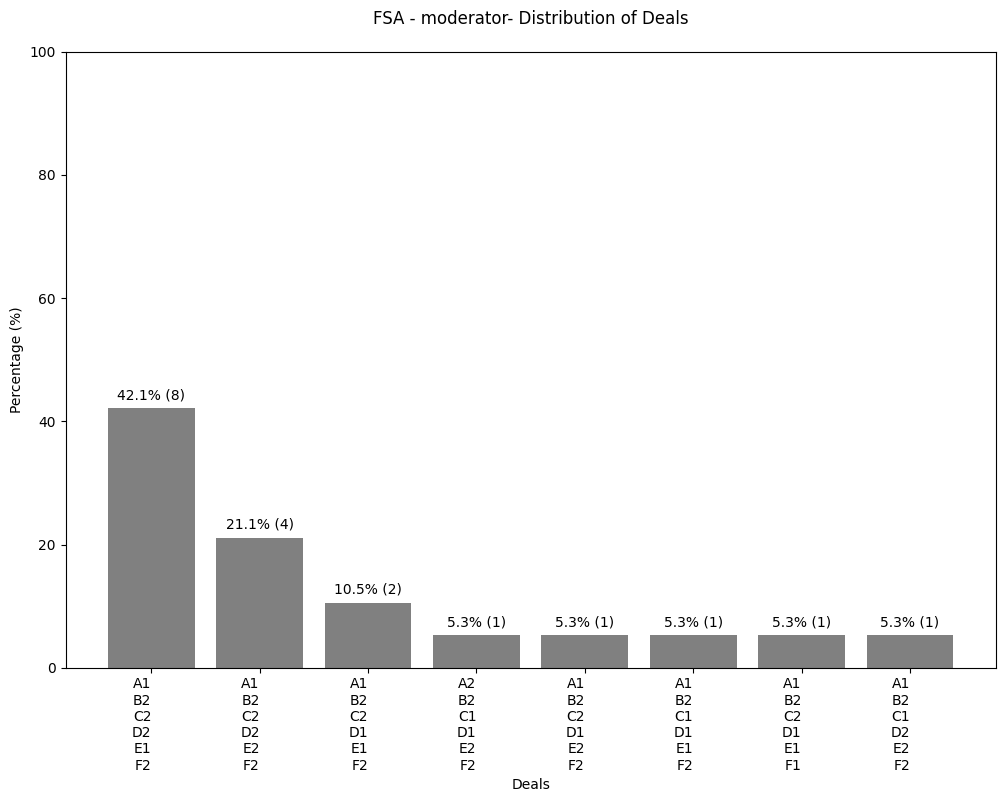

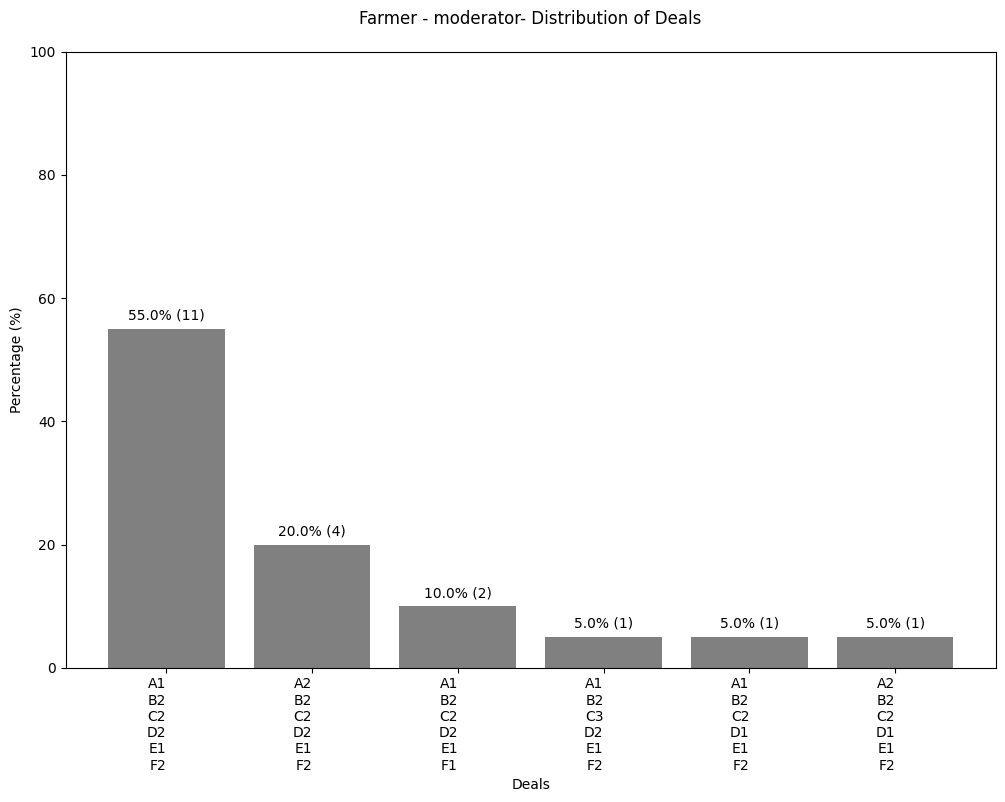

In [1]:
# @title Agreed deals plots

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get file path from user input
file_path = input("Please enter the path to the Excel file: ")

# Ask if the user wants to save plots as PNGs
save_plots_str = input("Do you want to save the plots as PNGs? (yes/no): ")
save_plots = save_plots_str.lower() == 'yes'

# Function to plot distribution of unique option combinations per simulation round
def plot_combination_distribution(sheet_df, sheet_name):
    # Create a column that combines all the issue columns into a tuple
    issues_columns = sheet_df.columns[1:]  # Exclude the first column which is assumed to be an identifier
    sheet_df['Combination'] = sheet_df[issues_columns].apply(lambda row: tuple(row), axis=1)

    # Count the occurrences of each combination
    combination_counts = sheet_df['Combination'].value_counts(normalize=False)
    combination_percentages = (combination_counts / len(sheet_df)) * 100

    # Retrieve option lables
    letter_labels = [col for col in sheet_df.columns[1:] if sheet_df[col].notna().any()]
    # For the Combined case we plot horizontal labels, therefore, '-' used as a separator
    # whereas for the moderator cases '\n', since the orientation is vertical
    if sheet_name == "Combined":
        combination_patterns = ['-'.join([f'{letter}{num}' for letter, num in zip(letter_labels, comb)]) for comb in combination_counts.index]
    else:
        combination_patterns = ['\n'.join([f'{letter}{num}' for letter, num in zip(letter_labels, comb)]) for comb in combination_counts.index]

    # Plotting
    plt.figure(figsize=(12, 8))

    if sheet_name == "Combined":
        y = np.arange(len(combination_patterns))
        plt.barh(y, combination_percentages, color='limegreen')
        plt.yticks(y, combination_patterns, ha='right')
        plt.title(f'{sheet_name} - Distribution of Deals', pad=20)
    else:
        x = np.arange(len(combination_patterns))
        plt.bar(x, combination_percentages, color='grey')
        plt.xticks(x, combination_patterns, rotation=0, ha='right')
        plt.ylim(0, 100)
        plt.title(f'{sheet_name} - moderator- Distribution of Deals', pad=20)

    plt.xlabel('Deals')
    plt.ylabel('Percentage (%)')

    # Add percentage labels on top of the bars with absolute counts
    for bar, abs_count in zip(plt.gca().patches, combination_counts):
      if sheet_name == "Combined":
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}% ({abs_count})',
                     va='center', ha='left')
      else:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}% ({abs_count})', ha='center', va='bottom')

    # Save the figure with the corresponding name, uncomment if needed
    if save_plots:
      filename = f'{sheet_name}_Unique_Combination_Distribution.png'
      plt.savefig(filename, bbox_inches='tight')
    plt.show()

# Load and plot the data for each sheet with combination distributions
#sheet_names=['Consumer', 'FSA', 'Farmer', 'Combined']
sheet_names=[sheet for sheet in pd.ExcelFile(file_path).sheet_names if sheet not in ["Best_options"]]
for sheet_name in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    plot_combination_distribution(df, sheet_name)

## Plots for individual Issues

The Script generates diagrams for the distribution of choices between the
options for each raised issue.

Orange color highlights a preferred option for a given issue for a chosen
moderator (additionally specified in the Figure title).



*   **Input:** Path (*string*) to an Excel file with the stored deals and a decision whether the generated plots should be saved as *PNG*s
*   **Output:** Bar charts for the option preferences for each issue for all simulations.





Please enter the path to the Excel file: /content/Results_overview_Bt_plots.xlsx
Do you want to save the plots as PNGs? (yes/no): no


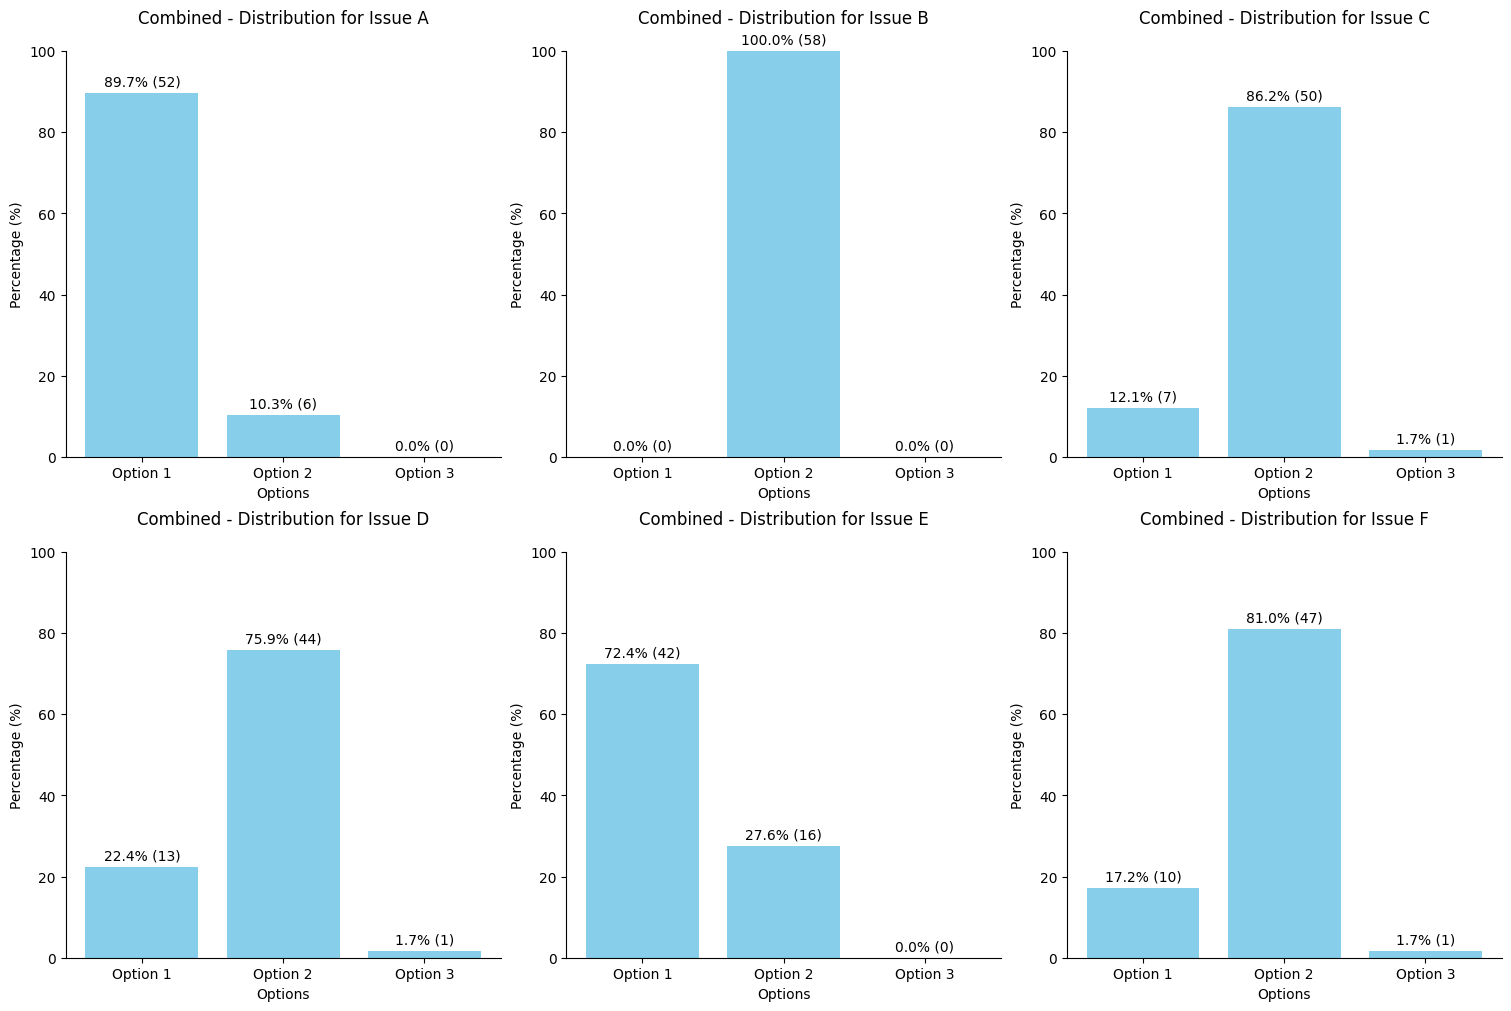

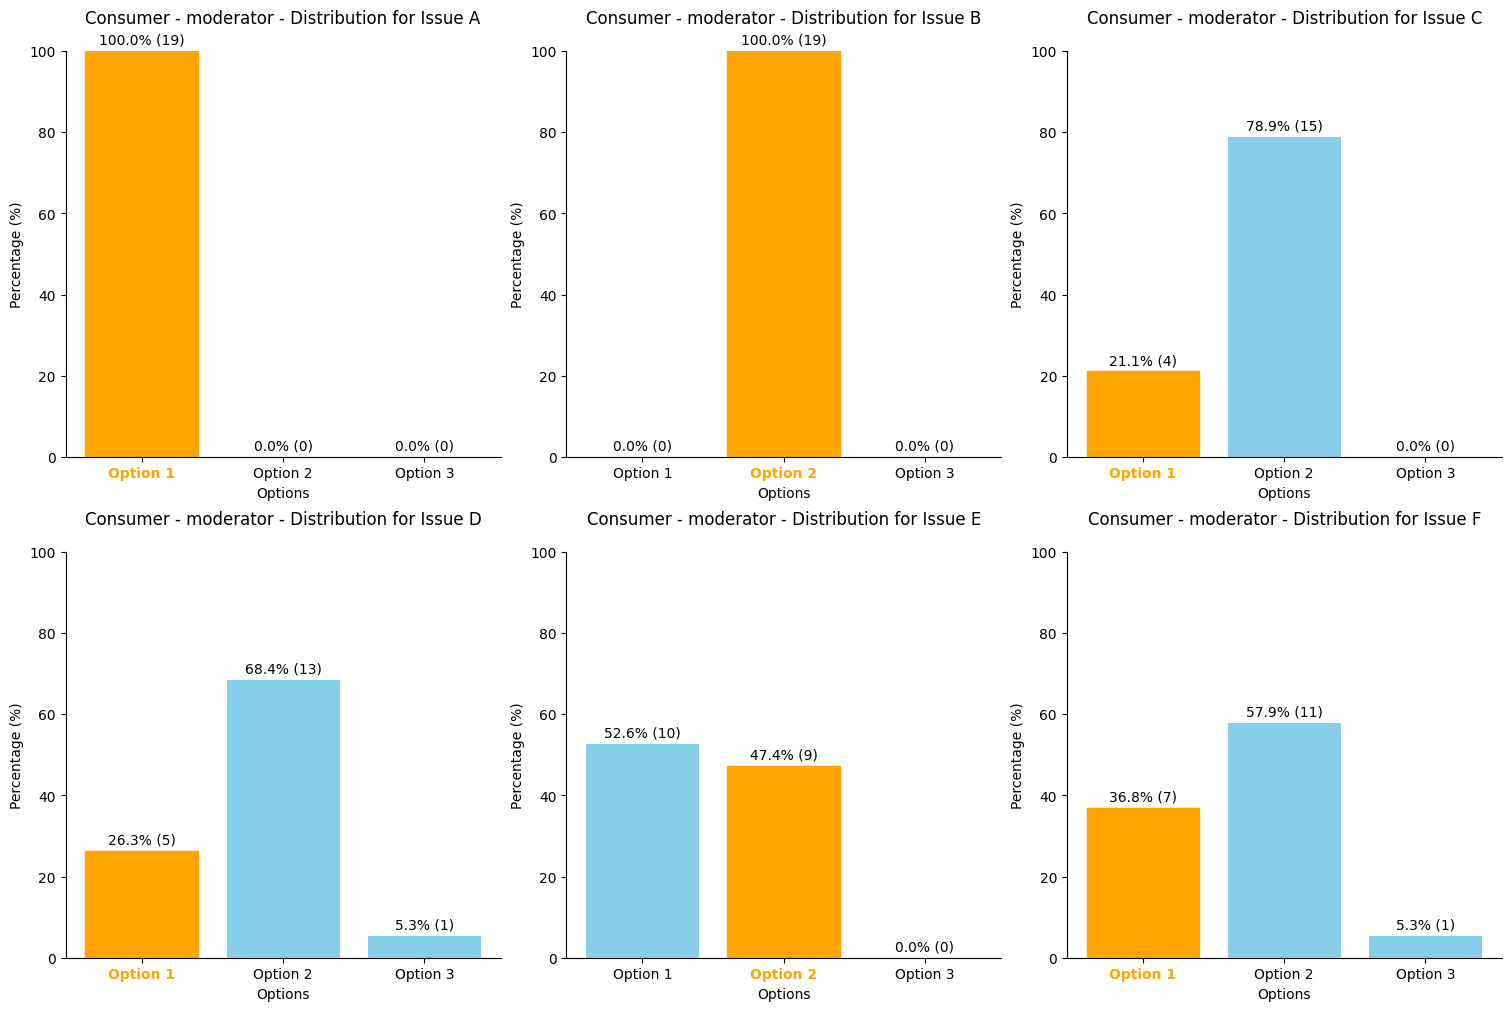

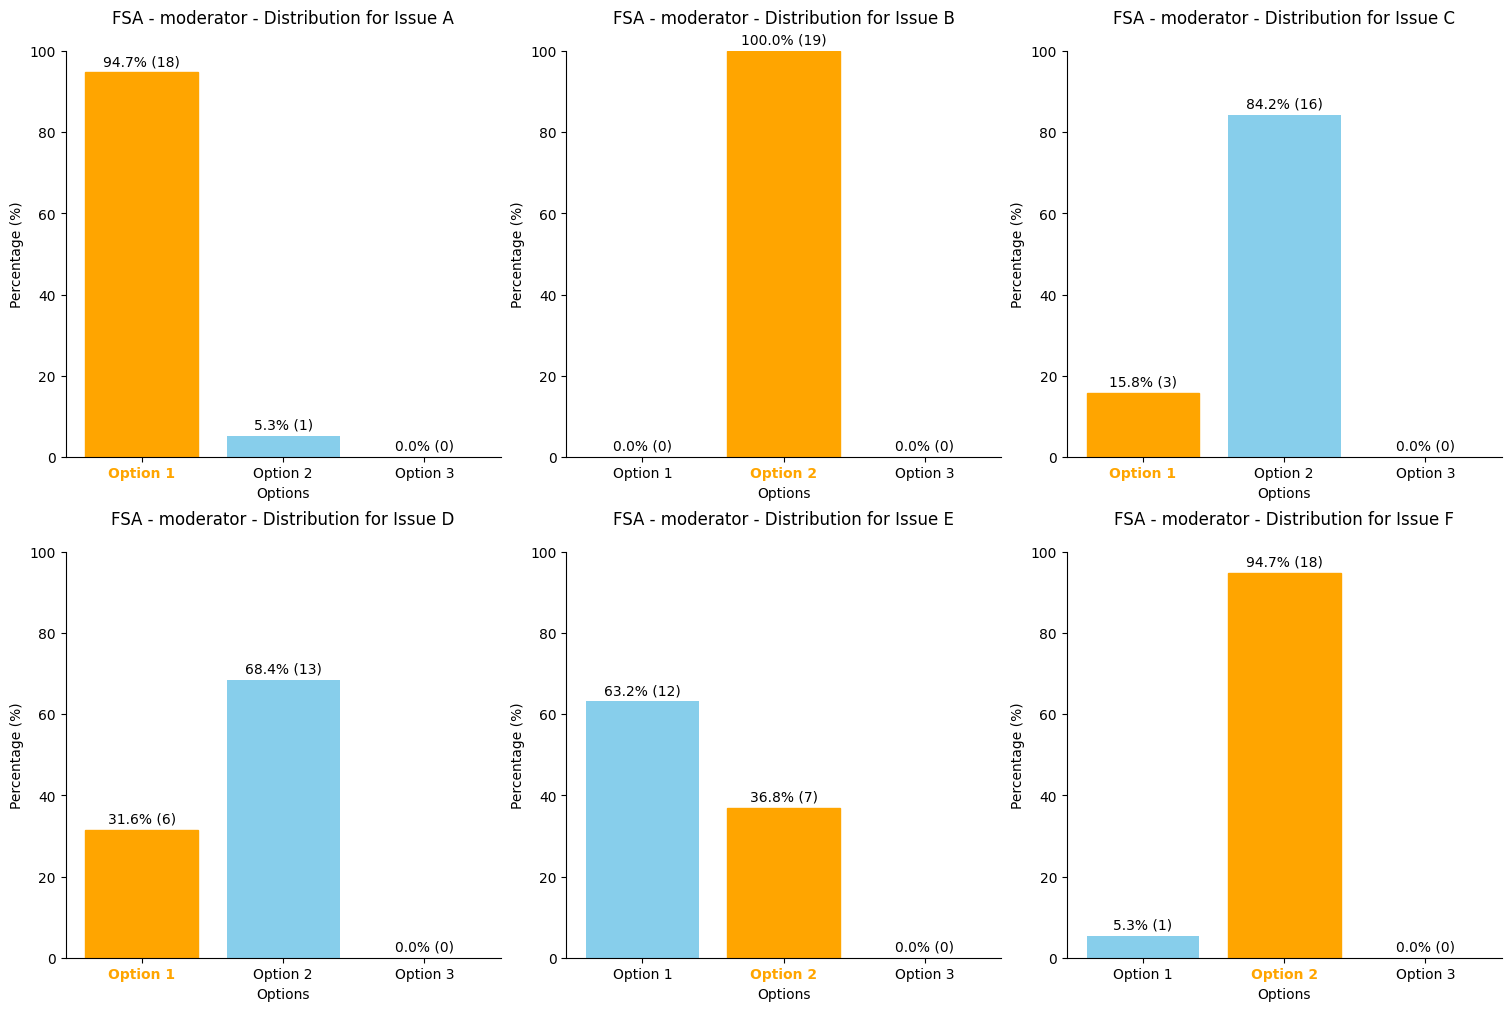

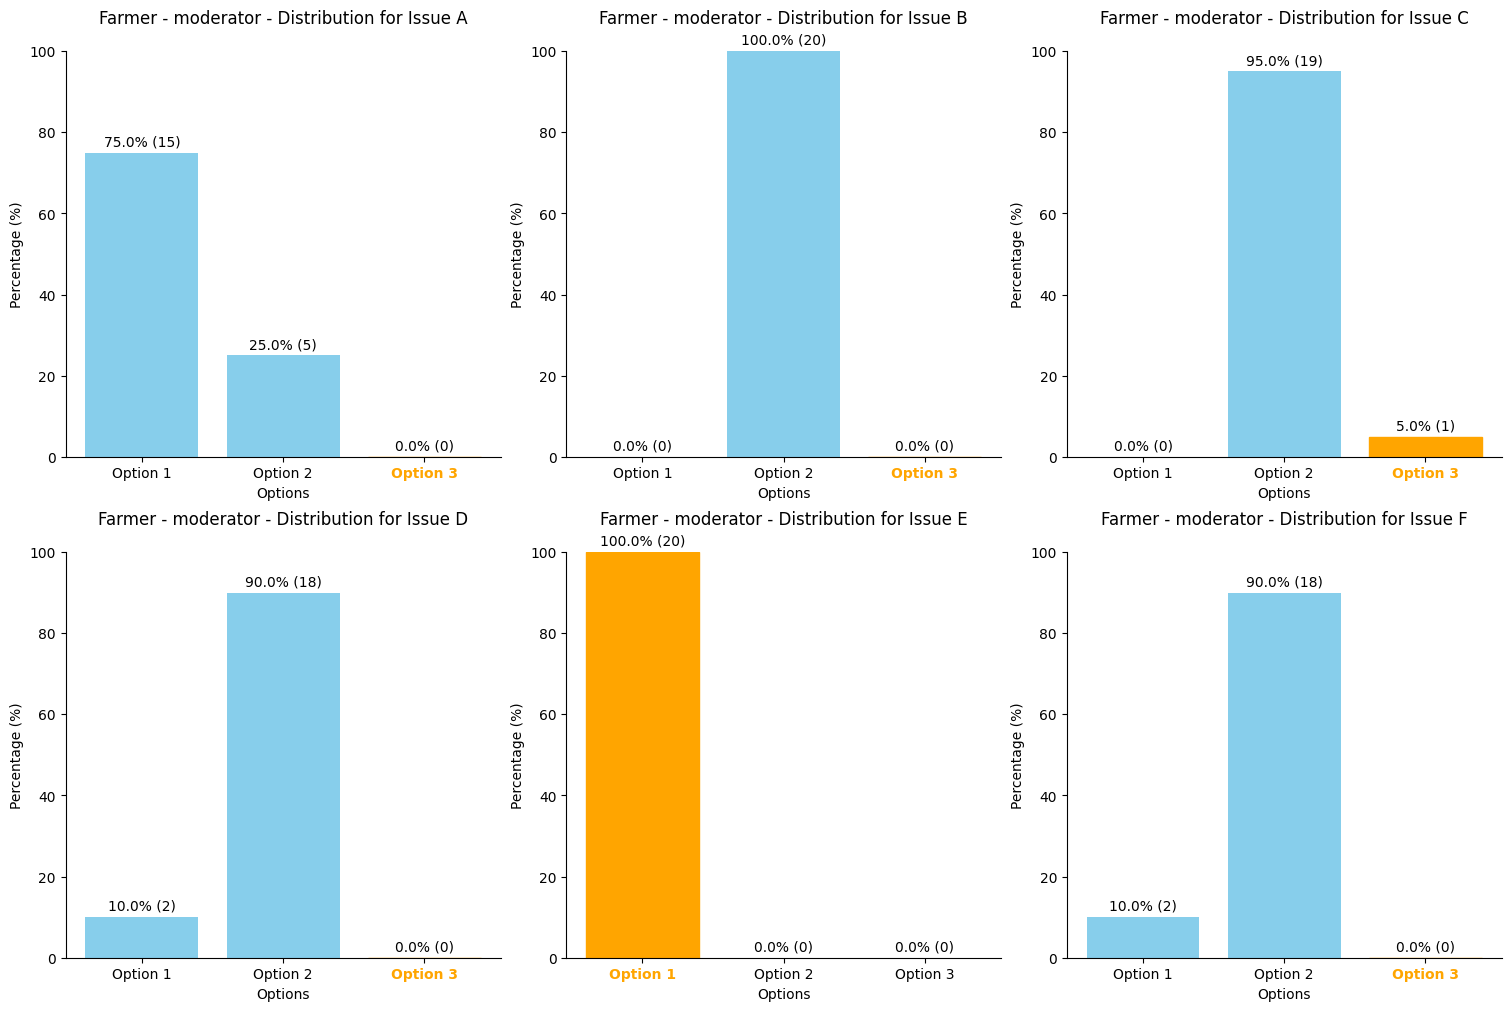

In [4]:
# @title Distributions for individual issues

import pandas as pd
import matplotlib.pyplot as plt


# Get file path from user input
file_path = input("Please enter the path to the Excel file: ")

# Ask if the user wants to save plots as PNGs
save_plots_str = input("Do you want to save the plots as PNGs? (yes/no): ")
save_plots = save_plots_str.lower() == 'yes'

# Function to load highlight options and number of options for each issue from "Best_options" sheet
def load_highlight_and_option_count(file_path):
    # Retrieve all sheet names, excluding "Best_options" and "Combined"
    all_sheets = pd.ExcelFile(file_path).sheet_names
    data_sheets = [sheet for sheet in all_sheets if sheet not in ["Best_options"]]

    best_options_df = pd.read_excel(file_path, sheet_name="Best_options", header=None)

    # Identify row with the number of options
    option_counts = best_options_df[best_options_df[0] == 'Number of options'].iloc[0, 1:].astype(int).tolist()

    # Load the highlight options for dynamically retrieved sheet names
    highlight_options = {}
    for i, row in best_options_df.iterrows():
        if row[0] in data_sheets:
            stakeholder = row[0]
            options = row[1:].tolist()
            highlight_options[stakeholder] = options
    return highlight_options, option_counts, data_sheets

# Modified function to include percentages on top of each bar

def plot_distribution_with_percentages(sheet_df, sheet_name, highlight_options, option_counts, save_plots):
    issues = sheet_df.columns[1:]  # Exclude the first column which is assumed to be an identifier
    num_issues = len(issues)
    num_cols = 3  # Number of plots per line
    num_rows = (num_issues + num_cols - 1) // num_cols  # Calculate required rows

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)
    axes = axes.flatten()  # Flatten axes for easier iteration

    for idx, issue in enumerate(issues):
        num_options = option_counts[idx]  # Number of options for this issue
        options = list(range(1, num_options + 1))  # Generate options dynamically

        issue_counts = sheet_df[issue].value_counts(normalize=True).reindex(options, fill_value=0) * 100
        absolute_counts = sheet_df[issue].value_counts().reindex(options, fill_value=0)

        ax = axes[idx]
        option_labels = [f'Option {i}' for i in options]
        bars = ax.bar(option_labels, issue_counts, color='skyblue')
        ax.set_ylim(0, 100)
        ax.set_xlabel('Options')
        ax.set_ylabel('Percentage (%)')

        # Remove the box around the plot
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)

        # Set title with or without "-moderator"
        if sheet_name == "Combined":
            ax.set_title(f'{sheet_name} - Distribution for Issue {issue}', pad=20)
            filename = f'{sheet_name}_Issue_{issue}.png'
        else:
            ax.set_title(f'{sheet_name} - moderator - Distribution for Issue {issue}', pad=20)
            filename = f'{sheet_name}_moderator_Issue_{issue}.png'

        # Highlight specific options from loaded highlight_options
        if sheet_name in highlight_options:
            highlight_index = highlight_options[sheet_name][idx] - 1
            bars[highlight_index].set_color('orange')
            ax.get_xticklabels()[highlight_index].set_color('orange')  # Highlight x-label
            ax.get_xticklabels()[highlight_index].set_fontweight('bold')

        # Add percentage labels on top of the bars with absolute counts
        for bar, abs_count in zip(bars, absolute_counts):
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, yval + 1, f'{yval:.1f}% ({abs_count})', ha='center', va='bottom')

        if save_plots:
            plt.savefig(filename, bbox_inches='tight')

    # Hide any unused subplots
    for ax in axes[len(issues):]:
        ax.axis('off')

    plt.show()

# Load the highlighting options, option counts, and data sheet names from "Best_options" sheet
highlight_options, option_counts, data_sheets = load_highlight_and_option_count(file_path)

# Plot the data for each sheet with percentages
for sheet_name in data_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    plot_distribution_with_percentages(df, sheet_name, highlight_options, option_counts, save_plots)


# 3D visualization of the simulated negotiation flow

## Stakeholder's preferences visualization

The Code provides a visualization of the individual stakeholder preferences and the mean across the preferences in a form of 3D plot. The axes are: Issues (A ,B , C etc.), Options (A1-A3, B1-B3 etc.) and stakeholder's preference scores for each option (30 points for A1, 10 for A2 0 for A3, 20 for B1 etc.). User can rotate and scale the plots by using a PC mouse. For visualization purposes the scores are plotted with a minus sign


*   **Input:** Option scores for the stakeholders (included in the script)
*   **Output:** 3D plots featuring the stakeholder preferences and the mean across the preferences


In [7]:
# @title Initial conditions adapted to Bt example

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pandas as pd

# The user provides the path the excel file
file_path = input("Please enter the path to the Excel file containing preferences: ")

# Initialize the dictionary to store scores
excel_file = pd.ExcelFile(file_path) # Load the Excel file
scores_data = {}

#Loop through all the sheet names dynamically
for sheet_name in excel_file.sheet_names:
    # Read the sheet data
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    # Initialize a dictionary for the current stakeholder
    combined_data = {}

    for col in df.columns:
        option = col[0]  # Extract the letter, e.g., 'A' from 'A1', 'A2', ...

        if option not in combined_data: # check whether the key exists in the dictionary and make it if needed
            combined_data[option] = []

        # Convert column data to numeric and drop NaN values
        valid_values = pd.to_numeric(df[col], errors='coerce').dropna()
        combined_data[option].append(int(valid_values.iloc[0]))

    # Store the combined data in the final structure
    scores_data[sheet_name] = combined_data


# Data for each stakeholder, manual entry for the debugging
# scores_data = {
#     "Consumer": {
#         'A': [50, 10, 0], 'B': [10, 10, 0], 'C': [15, 3, 0],
#         'D': [5, 2, 1], 'E': [0, 0, 0], 'F': [20, 0, 0]
#     },
#     "Farmer": {
#         'A': [0, 1, 12], 'B': [0, 1, 3], 'C': [0, 1, 5],
#         'D': [1, 1, 7], 'E': [70, 5, 0], 'F': [0, 1, 3]
#     },
#     "Food Safety Authority": {
#         'A': [50, 20, 0], 'B': [3, 8, 0], 'C': [15, 7, 0],
#         'D': [10, 4, 0], 'E': [0, 8, 4], 'F': [1, 9, 0]
#     }
# }

# List of issues and options
#issue_labels = list(scores_data["Consumer"].keys())
issue_labels = list(scores_data[next(iter(scores_data.keys()))].keys()) # take the first key from the scores_data and take the keys from it.
options_points = np.array([1, 2, 3])  # Fixed as exactly three options, strictly [1, 2, 3]

# Prepare data for plotting
issues_indices = np.arange(len(issue_labels))

# Calculate means for each issue across all stakeholders
mean_scores = {issue: np.mean([scores_data[stakeholder][issue] for stakeholder in scores_data], axis=0) for issue in issue_labels}

# Function to create a 3D surface plot
def create_surface_plot(title, scores, row, col):
    # Prepare Z array without transposing to ensure (3, 6) shape directly
    Z = np.array([scores[issue] for issue in issue_labels]).T  # Shape (3, 6)

    # Debugging
   # if title == "Consumer Scores":
    #    print("Debugging Consumer Scores Plot:")
     #   print("X:", issues_indices)
      #  print("Y:", options_points)
       # print("Z:", Z)
        #print("Z Shape:", Z.shape)

    # Verify that shape is exactly (3, 6)
    #if Z.shape != (3, 6):
      #  raise ValueError(f"Unexpected Z shape for {title}: {Z.shape}")

    X, Y = np.meshgrid(issues_indices, options_points)  # Ensure meshgrid shape matches Z

    Z = -Z # depth effect

    surface = go.Surface(
        z=Z,
        x=X,
        y=Y,
        colorscale='Viridis',
        showscale=(row == 2 and col == 2),  # Only show color scale for the mean plot
        colorbar=dict(title='Scores') if (row == 2 and col == 2) else None  # Add colorbar only on mean scores
    )
    fig.add_trace(surface, row=row, col=col)

    # Update axes and layout for each subplot to ensure three options on y-axis
    fig.update_scenes(
        dict(
            xaxis=dict(
                tickmode='array',
                tickvals=issues_indices,
                ticktext=issue_labels,
                title='Issues'
            ),
            yaxis=dict(
                tickmode='array',
                tickvals=options_points,
                ticktext=['1', '2', '3'],  # Explicitly set only three options
                title='Options'
            ),
            zaxis=dict(title='Scores', range=[-70, 0]),  # Reverse depth
            aspectmode='cube'
        ),
        row=row, col=col
    )

# Create subplots with three plots in the first row and one centered in the second row
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}],
           [None, {'type': 'surface'}, None]],
    subplot_titles=[
        "Consumer Scores",
        "Farmer Scores",
        "Food Safety Authority Scores",
        "Mean Scores Across Stakeholders"
    ],
    horizontal_spacing=0.05,
    vertical_spacing=0.15  # Increase vertical spacing to prevent overlap
)

# Add individual stakeholder plots
create_surface_plot("Consumer Scores", scores_data["Consumer"], row=1, col=1)
create_surface_plot("Farmer Scores", scores_data["Farmer"], row=1, col=2)
create_surface_plot("Food Safety Authority Scores", scores_data["Food Safety Authority"], row=1, col=3)

# Add mean scores plot in the center of the second row
create_surface_plot("Mean Scores Across Stakeholders", mean_scores, row=2, col=2)

# Update layout with title and spacing
fig.update_layout(
    title="3D Surface Plots of Scores for Different Stakeholders and Mean Score",
    title_x=0.5,  # Center the main title
    height=1000,  # Increase height for better spacing
    showlegend=False,
    scene=dict(aspectmode='cube'),
    scene2=dict(aspectmode='cube'),
    scene3=dict(aspectmode='cube'),
    scene4=dict(aspectmode='cube'),
)

# Increase font size for subplot titles
for i in range(len(fig.layout.annotations)):
    fig.layout.annotations[i].font.size = 14  # Adjust subplot title font size

fig.show()


Please enter the path to the Excel file containing preferences: /content/Preferences_Bt_plots.xlsx


## Negotiation flow visualization
The Script plots the simulated negotiation flow among the stakeholders.

*   **Input:** Deals suggested by the stakeholders during the negotiation simulation (`answers.json` file produced during the simulation), the stakeholder preferences (included in the script)
*   **Output:** Combination of plots

1.   3D plots featuring how deals suggested by the stakeholders (red dots) are aligned with the stakeholder preferences (3D surfaces)
2.   2D chart depicting deal score changes during the negotiation
3.   The list of deals/stakeholders proposed that deal

In [8]:
# @title Negotiation flow adapted to Bt case
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display

# Load the JSON file

file_path = input("Please enter the path to json file containing answers produced during the simulation: ")
with open(file_path) as f:
    data = json.load(f)

# Step 1: Extract <DEAL> sequences and their proposers from rounds in the JSON file
deals_data = []
#Assuming the first element of each sublist is the proposer and the second is the deal
for round_data in data['rounds']:
    proposer = round_data[0] if len(round_data) > 0 else 'Moderator' # Extract proposer, default to 'Moderator' if empty
    deal = round_data[1] if len(round_data) > 1 else ''  # Extract deal, default to '' if empty

    # Extract the deal string from the message
    deal_match = re.search(r"<DEAL>(.*?)</DEAL>", deal)
    deal_text = deal_match.group(1).strip() if deal_match else ''

    deals_data.append({'deal': deal_text, 'proposer': proposer})

# separately extract the final deal
deal=data['voting_sessions']['0']['deal_suggestion']
deal_match = re.search(r"<DEAL>(.*?)</DEAL>", deal)
deal_text = deal_match.group(1).strip() if deal_match else ''
deals_data.append({'deal': deal_text, 'proposer': data['rounds'][0][0]}) # the first proposal comes from the moderator


# Step 2: Process the deals into coordinates and build the dictionary
deals_dict = {}
deals_coordinates = []
for i, deal_entry in enumerate(deals_data):
    deal_text = deal_entry['deal']
    proposer = deal_entry['proposer']
    coordinates = []
    for option in deal_text.split(', '):
        if len(option) == 2 and option[1].isdigit():  # Check for proper format
            x_coord = option[0]  # E.g., 'A'
            y_coord = int(option[1])  # E.g., '1'
            coordinates.append((x_coord, y_coord))
    deals_coordinates.append(coordinates)
    deals_dict[i] = {'deal': deal_text, 'proposer': proposer}

# Sample scores from previous task, with scores inverted for depth effect
# Scores to be uploaded
scores_data = {
    "Consumer": {
        'A': [-50, -10, 0], 'B': [-10, -10, 0], 'C': [-15, -3, 0],
        'D': [-5, -2, -1], 'E': [0, 0, 0], 'F': [-20, 0, 0]
    },
    "Farmer": {
        'A': [0, -1, -12], 'B': [0, -1, -3], 'C': [0, -1, -5],
        'D': [-1, -1, -7], 'E': [-70, -5, 0], 'F': [0, -1, -3]
    },
    "Food Safety Authority": {
        'A': [-50, -20, 0], 'B': [-3, -8, 0], 'C': [-15, -7, 0],
        'D': [-10, -4, 0], 'E': [0, -8, -4], 'F': [-1, -9, 0]
    }
}

# Calculate mean scores for each issue across all stakeholders
mean_scores = {issue: np.mean([scores_data[stakeholder][issue] for stakeholder in scores_data], axis=0)
               for issue in scores_data["Consumer"]}

# Function to calculate the deal score for a stakeholder
def calculate_deal_score(scores, deal_coords):
    return abs(sum(scores[coord[0]][coord[1] - 1] for coord in deal_coords))

# Function to calculate scores for all deals
def calculate_all_deal_scores():
    deal_scores = {
        "Consumer": [],
        "Farmer": [],
        "Food Safety Authority": []
    }
    for deal_coords in deals_coordinates:
        for stakeholder in deal_scores.keys():
            score = calculate_deal_score(scores_data[stakeholder], deal_coords)
            deal_scores[stakeholder].append(score)
    return deal_scores

# Compute all deal scores
all_deal_scores = calculate_all_deal_scores()

# Function to plot the line chart for all deals
def plot_deal_scores(ax, all_scores, selected_deal):
    x = list(range(1, len(deals_coordinates) + 1))  # Start x-axis from 1
    ax.plot(x, all_scores["Consumer"], label="Consumer", marker='o', color='blue')
    ax.plot(x, all_scores["Farmer"], label="Farmer", marker='o', color='green')
    ax.plot(x, all_scores["Food Safety Authority"], label="Food Safety Authority", marker='o', color='orange')

    # Add a vertical dashed line for the selected deal
    ax.axvline(x=selected_deal + 1, color='red', linestyle='--', label=f"Selected Deal: {selected_deal + 1}")
    ax.axhline(y=65, color='black', linestyle='-', label='Acceptance Level')

    ax.set_title("Scores for All Deals")
    ax.set_xlabel("Deal Number")
    ax.set_ylabel("Obtained Score")
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.35),
        ncol=3,
        borderaxespad=0.,
        frameon=False
    )
    ax.grid(True)

# Function to plot individual 3D surface plot with line
def plot_3d_with_line(ax, scores, deal_coords, title):
    issues = list(scores.keys())
    X, Y = np.meshgrid(range(len(issues)), [1, 2, 3])
    Z = np.array([scores[issue] for issue in issues])

    # Compute the deal score
    deal_score = calculate_deal_score(scores, deal_coords)

    # Plot surface
    ax.plot_surface(X, Y, Z.T, cmap='viridis', edgecolor='k', alpha=0.7)
    ax.set_title(f"{title}\nDeal Score: {deal_score}")
    ax.set_xlabel('Issues')
    ax.set_ylabel('Options')
    ax.set_zlabel('Scores')
    ax.set_xticks(range(len(issues)))
    ax.set_xticklabels(issues)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(['1', '2', '3'])

    # Plot the line for the deal
    x_line = [issues.index(coord[0]) for coord in deal_coords]
    y_line = [coord[1] for coord in deal_coords]
    z_line = [scores[issues[issues.index(coord[0])]][coord[1] - 1] for coord in deal_coords]
    ax.plot(x_line, y_line, z_line, color='red', marker='o', markersize=15)

# Function to plot mean surface and mean deal line
def plot_mean_surface(ax, mean_scores, deal_coords):
    issues = list(mean_scores.keys())
    X, Y = np.meshgrid(range(len(issues)), [1, 2, 3])
    Z = np.array([mean_scores[issue] for issue in issues])

    # Compute the deal score for the mean
    deal_score = calculate_deal_score(mean_scores, deal_coords)

    # Plot mean surface
    ax.plot_surface(X, Y, Z.T, cmap='viridis', edgecolor='k', alpha=0.7)
    ax.set_title(f"Mean Scores Across Stakeholders\nDeal Score: {deal_score:.1f}")
    ax.set_xlabel('Issues')
    ax.set_ylabel('Options')
    ax.set_zlabel('Scores')
    ax.set_xticks(range(len(issues)))
    ax.set_xticklabels(issues)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(['1', '2', '3'])

    # Plot the mean deal line
    x_line = [issues.index(coord[0]) for coord in deal_coords]
    y_line = [coord[1] for coord in deal_coords]
    z_line = [mean_scores[issues[issues.index(coord[0])]][coord[1] - 1] for coord in deal_coords]
    ax.plot(x_line, y_line, z_line, color='red', marker='o', markersize=15)


# Update function for interactive plots
def update_plots(deal_index):
    fig = plt.figure(figsize=(15, 12))
    gs = plt.GridSpec(2, 3, figure=fig)

    # Subplots
    ax_consumer = fig.add_subplot(gs[0, 0], projection='3d')
    ax_farmer = fig.add_subplot(gs[0, 1], projection='3d')
    ax_food_safety = fig.add_subplot(gs[0, 2], projection='3d')
    ax_deals_list = fig.add_subplot(gs[1, 1])
    ax_scores = fig.add_subplot(gs[1, 0])
    ax_mean = fig.add_subplot(gs[1, 2], projection='3d')

    # Plot scores for all deals
    plot_deal_scores(ax_scores, all_deal_scores, deal_index)

    # Plot the individual 3D views
    plot_3d_with_line(ax_consumer, scores_data["Consumer"], deals_coordinates[deal_index], "Consumer Scores")
    plot_3d_with_line(ax_farmer, scores_data["Farmer"], deals_coordinates[deal_index], "Farmer Scores")
    plot_3d_with_line(ax_food_safety, scores_data["Food Safety Authority"], deals_coordinates[deal_index], "Food Safety Authority Scores")

    # Plot the mean surface and deal line
    plot_mean_surface(ax_mean, mean_scores, deals_coordinates[deal_index])

    # Display list of deals and their proposers
    ax_deals_list.axis('off')
    for i, deal_entry in enumerate(deals_dict.values()):
        deal_text = deal_entry['deal']
        proposer = deal_entry['proposer']
        deal_number = f"{i + 1}."
        if i == 0:  # First deal
          annotation = "(initial proposal) "
        elif i == len(deals_dict) - 1:  # Last deal
          annotation = "(suggested deal) "
        else:
          annotation =''
        if i == deal_index:
            ax_deals_list.text(0.1, 0.9 - 0.05 * i, f"{annotation}{deal_number} | {deal_text} by {proposer}",
                               color='red', fontweight='bold', fontsize=10)
        else:
            ax_deals_list.text(0.1, 0.9 - 0.05 * i, f"{annotation}{deal_number} | {deal_text} by {proposer}",
                               color='black', fontsize=10)
    ax_deals_list.set_title("List of Deals", fontsize=12, fontweight='bold')

    plt.subplots_adjust(
        left=0.05,    # Space on the left of the plots
        right=0.95,   # Increase right margin to accommodate Z-axis label
        top=0.85,     # Reduce top margin for more space
        bottom=0.2,   # Increase bottom margin for slider
        wspace=0.4,   # Width space between plots
        hspace=0.6    # Height space between plots
    )

    #plt.tight_layout()
    plt.show()

# Interactive slider widget
deal_slider = widgets.IntSlider(value=1, min=1, max=len(deals_coordinates), step=1, description="Deal:")
output = widgets.Output()

# Handle slider change
def on_slider_change(change):
    with output:
        output.clear_output(wait=True)
        update_plots(change['new'] - 1)

deal_slider.observe(on_slider_change, names='value')

# Display the slider and plots
display(widgets.VBox([deal_slider, output]))
with output:
    update_plots(0)


Please enter the path to json file containing answers produced during the simulation: /content/answers10_00_02.json


## Individual conversations

Code extracts the agent reasoning that caused the observed deal suggestions (see List of Deals in *Negotiation flow*)

*   **Input:** File containing a complete negotiation simulation (`full_conversation.json` file produced during the simulation)

*   **Output:** Part of the negotiation simulation containing agentic thoughts. Saved as *TXT* files: one file for one proposed deal. Numbering matches the list of deals from *Negotiation flow* part

In [9]:
# @title Thoughts behind the suggested deals
import json
import os

# Load JSON file
file_path= input("Please enter the path to full_conversation.json file containing answers produced during the simulation. The extracted agent reasoning is saved in a separate folder ")
output_dir = '/content/thoughts'

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

with open(file_path, 'r') as f:
    data = json.load(f)

# Extract the relevant data
rounds = data.get('rounds', {}).get('answers', [])

for idx, entry in enumerate(rounds):
    if len(entry) >= 2:
        stakeholder_name = entry[0].strip()
        thoughts = entry[1].strip()

        # Process the lines of thoughts to replace escape sequences
        structured_thoughts = thoughts.replace('\\n', '\n').replace('\n', '\n').replace('\\t', '\t')

        # Define the output filename
        filename = f"{idx+2}_{stakeholder_name}_thoughts.txt" # +1 to account for the indexing starting at 0. +1 as the first deal is the initial suggestion
        filepath = os.path.join(output_dir, filename)

        # Write to the file
        with open(filepath, 'w') as outfile:
            outfile.write(structured_thoughts)

print(f"Processed thoughts saved in directory: {output_dir}")


Please enter the path to full_conversation.json file containing answers produced during the simulation. The extracted agent reasoning is saved in a separate folder /content/full_conversation10_00_02.json
Processed thoughts saved in directory: /content/thoughts
